# Desafio Técnico Keyrus — Bank Marketing

Data Scientist — desafio de modelagem em Python.

**Objetivo:** prever se um cliente vai assinar um depósito a prazo (`y`), a partir do dataset [Bank Marketing](https://www.kaggle.com/datasets/abdelazizsami/bank-marketing/data) (Kaggle), réplica do dataset público UCI de Moro et al. (2011).

Roteiro seguido (ver `docs/Teste_Modelagem_Python.pdf`): EDA → pré-processamento → modelagem → avaliação → interpretação → uso em produção.

## 0. Configuração e carregamento dos dados

Leitura direta do Kaggle via [`kagglehub`](https://github.com/Kaggle/kagglehub), sem baixar/versionar os CSVs no repositório.

O dataset traz dois arquivos (ver `docs/bank-names.txt`):
- `bank-full.csv`: todos os 45.211 exemplos.
- `bank.csv`: amostra de 10% (4.521 exemplos).

**Pré-requisito:** credenciais do Kaggle configuradas (`~/.kaggle/kaggle.json` ou variável `KAGGLE_API_TOKEN`). Sem isso, o download abaixo falha na autenticação.

In [1]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd

RANDOM_SEED = 42  # usada em todas as etapas do notebook que envolvam aleatoriedade

DATASET = "abdelazizsami/bank-marketing"

In [2]:
# O dataset original (Moro et al., 2011) usa ';' como separador de campos.
bank_full_df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    DATASET,
    "bank-full.csv",
    pandas_kwargs={"sep": ";"},
)

bank_df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    DATASET,
    "bank.csv",
    pandas_kwargs={"sep": ";"},
)

# 16 atributos de entrada + 1 alvo (y) = 17 colunas esperadas.
for nome, df in [("bank-full.csv", bank_full_df), ("bank.csv", bank_df)]:
    assert df.shape[1] == 17, (
        f"{nome}: esperadas 17 colunas, encontradas {df.shape[1]} — "
        "verifique o separador do CSV."
    )
    print(f"{nome}: {df.shape[0]} linhas, {df.shape[1]} colunas")

bank-full.csv: 45211 linhas, 17 colunas
bank.csv: 4521 linhas, 17 colunas


In [3]:
bank_full_df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [4]:
bank_df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


## 1. Análise Exploratória de Dados (EDA)

A partir daqui, `bank_full_df` (45.211 linhas) passa a ser o dataset principal de todo o desafio — inclusive nas próximas tarefas (pré-processamento e modelagem). `bank.csv` fica carregado na Seção 0 mas não é usado na EDA: a própria documentação do dataset (`docs/bank-names.txt`) o descreve como uma amostra de 10% pensada só para testar algoritmos computacionalmente caros (ex. SVM), não como base de um projeto completo — e mais dados reais disponíveis tendem a gerar uma EDA e um modelo mais robustos.

### 1.1 Estatísticas básicas e tipos de dados

In [5]:
print(f"Formato: {bank_full_df.shape[0]} linhas x {bank_full_df.shape[1]} colunas\n")
bank_full_df.info()

Formato: 45211 linhas x 17 colunas

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


In [6]:
# Listas reutilizadas nas subseções seguintes
NUM_COLS = ["age", "balance", "day", "duration", "campaign", "pdays", "previous"]
CAT_COLS = ["job", "marital", "education", "default", "housing", "loan", "contact", "month", "poutcome"]
assert set(NUM_COLS) | set(CAT_COLS) | {"y"} == set(bank_full_df.columns)

bank_full_df[NUM_COLS].describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [7]:
bank_full_df[CAT_COLS + ["y"]].describe()

,job,marital,education,default,housing,loan,contact,month,poutcome,y
count,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211
unique,12,3,4,2,2,2,3,12,4,2
top,blue-collar,married,secondary,no,yes,no,cellular,may,unknown,no
freq,9732,27214,23202,44396,25130,37967,29285,13766,36959,39922


### 1.2 Valores ausentes

In [8]:
# docs/bank-names.txt afirma "Missing Attribute Values: None" — e de fato não há NaN.
bank_full_df.isnull().sum().rename("nulos").to_frame()

,nulos
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [9]:
# Mas "unknown" é usado como valor em 4 colunas categóricas — ausência disfarçada de categoria.
unknown_cols = ["job", "education", "contact", "poutcome"]
unknown_summary = pd.DataFrame(
    {"unknown_qtd": [(bank_full_df[c] == "unknown").sum() for c in unknown_cols]},
    index=unknown_cols,
)
unknown_summary["unknown_pct"] = (unknown_summary["unknown_qtd"] / len(bank_full_df) * 100).round(1)
unknown_summary

,unknown_qtd,unknown_pct
job,288,0.6
education,1857,4.1
contact,13020,28.8
poutcome,36959,81.7


In [10]:
# pdays = -1 é outro sentinela de ausência: "cliente nunca contatado antes".
# Consistência esperada: pdays == -1 deve coincidir com previous == 0 e poutcome == "unknown".
pdays_never_contacted = (bank_full_df["pdays"] == -1).sum()
previous_zero = (bank_full_df["previous"] == 0).sum()
poutcome_unknown = (bank_full_df["poutcome"] == "unknown").sum()

print(f"pdays == -1 (nunca contatado antes): {pdays_never_contacted}")
print(f"previous == 0 (nenhum contato anterior): {previous_zero}")
print(f"poutcome == 'unknown':                {poutcome_unknown}")

pdays == -1 (nunca contatado antes): 36954
previous == 0 (nenhum contato anterior): 36954
poutcome == 'unknown':                36959


**Abordagem adotada:** não há `NaN` no sentido literal, mas `job`, `education`, `contact` e `poutcome` usam `"unknown"` como valor, e `pdays = -1` é um sentinela para "nunca contatado antes" — não são ausências aleatórias, têm significado próprio (ex.: `poutcome == "unknown"` é consistente com `previous == 0`, cliente que nunca foi contatado numa campanha anterior). Por isso, a decisão é **manter esses valores como categoria/sentinela própria**, sem imputação ou remoção de linhas. O tratamento formal (encoding) fica para a tarefa de Pré-processamento, a próxima do roteiro.

### 1.3 Visualização e análise de dados numéricos e categóricos

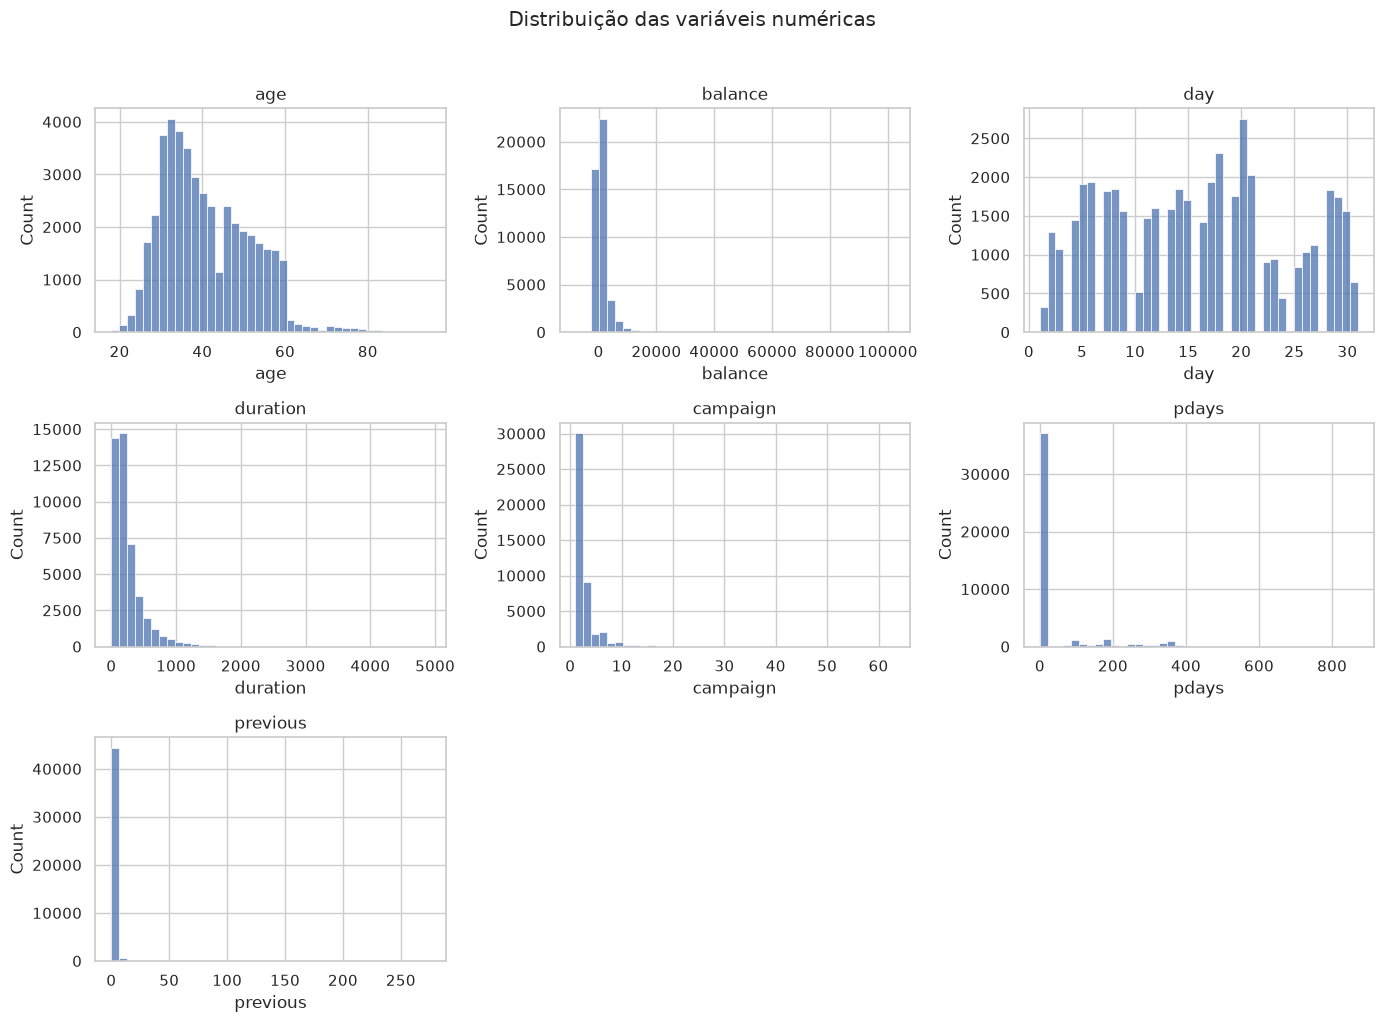

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()
for ax, col in zip(axes, NUM_COLS):
    sns.histplot(bank_full_df[col], bins=40, ax=ax)
    ax.set_title(col)
for ax in axes[len(NUM_COLS):]:
    ax.axis("off")
fig.suptitle("Distribuição das variáveis numéricas", y=1.02)
fig.tight_layout()
plt.show()

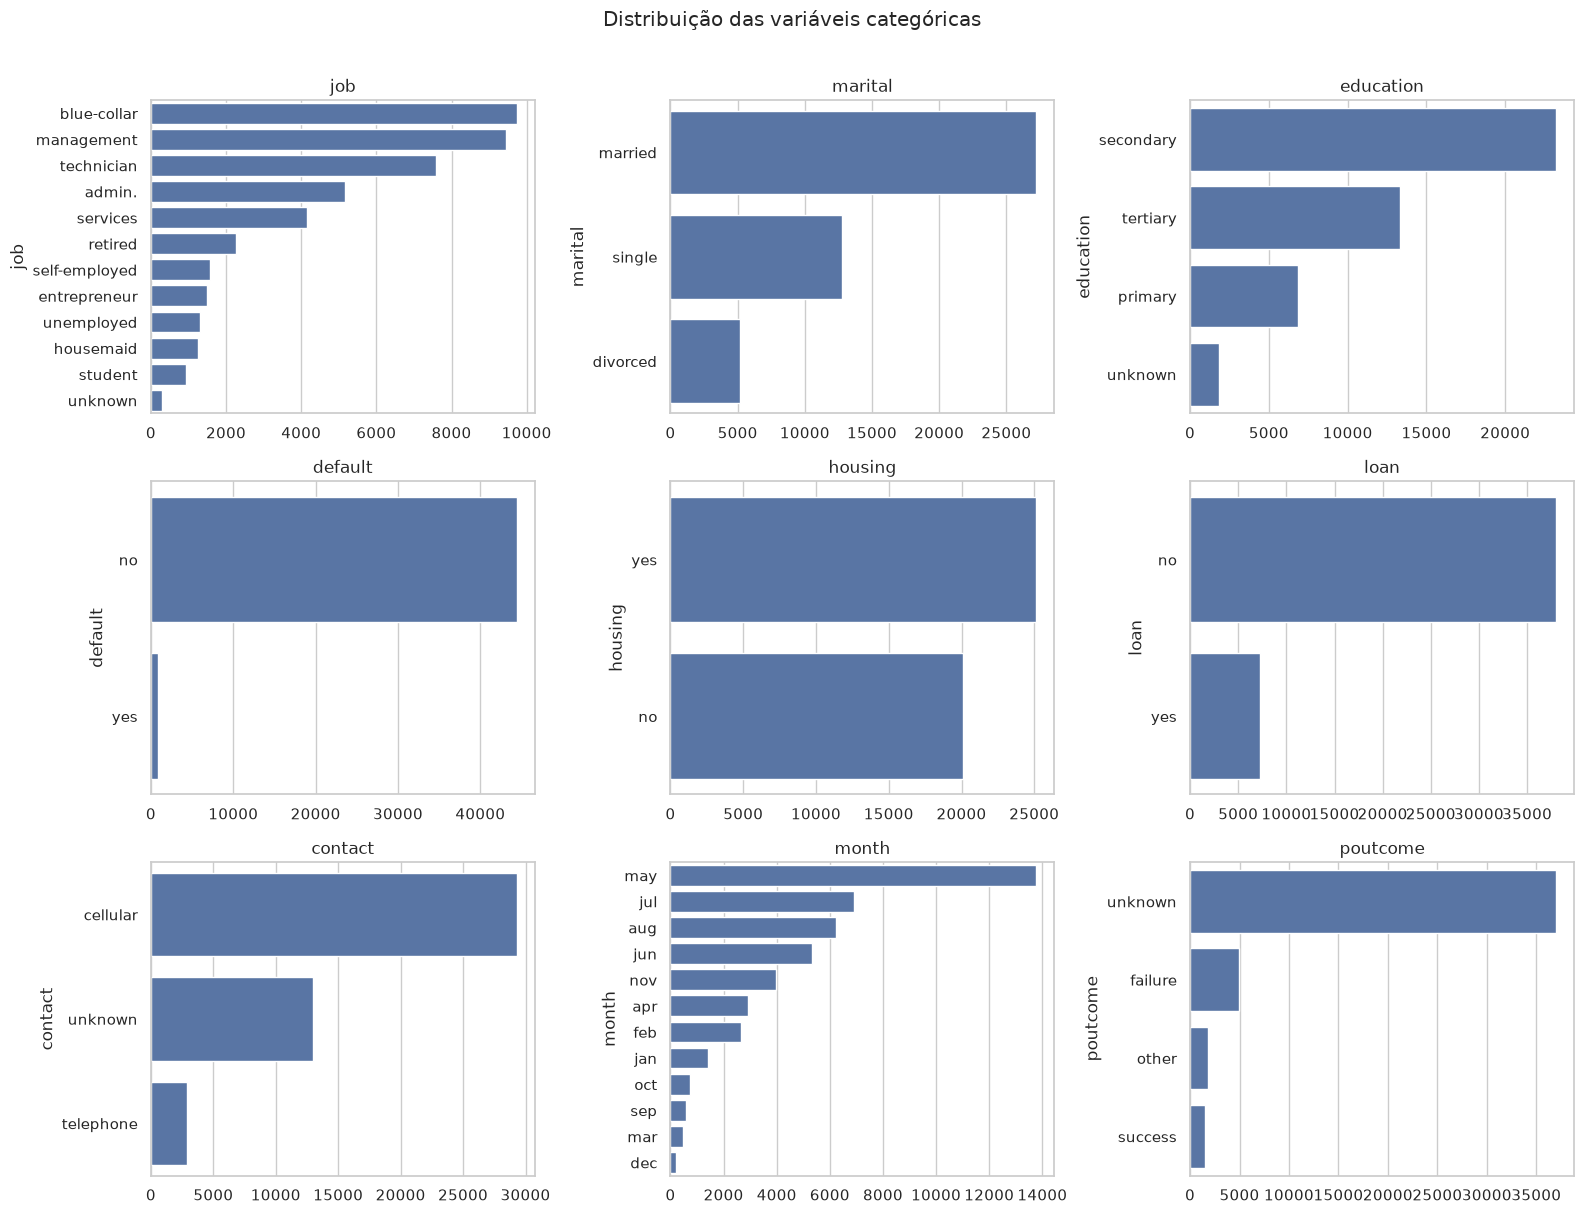

In [12]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for ax, col in zip(axes, CAT_COLS):
    order = bank_full_df[col].value_counts().index
    sns.countplot(data=bank_full_df, y=col, order=order, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
for ax in axes[len(CAT_COLS):]:
    ax.axis("off")
fig.suptitle("Distribuição das variáveis categóricas", y=1.01)
fig.tight_layout()
plt.show()

Distribuição de y:
y
no     88.3
yes    11.7
Name: proportion, dtype: float64


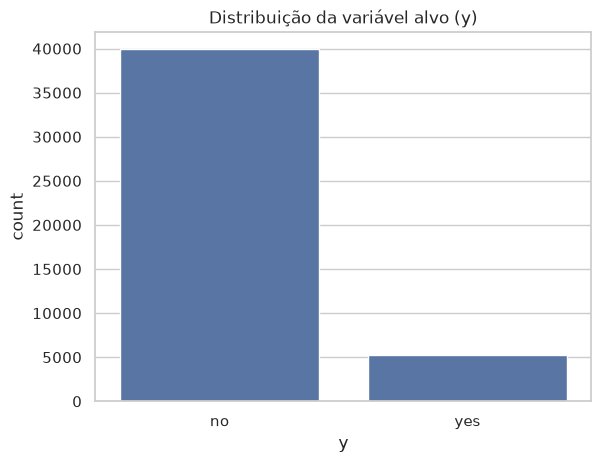

In [13]:
y_dist = bank_full_df["y"].value_counts(normalize=True).mul(100).round(1)
print(f"Distribuição de y:\n{y_dist}")

sns.countplot(data=bank_full_df, x="y")
plt.title("Distribuição da variável alvo (y)")
plt.show()

**Principais observações:** `y` é bastante desbalanceado (~88% "no" vs. ~12% "yes") — relevante para a escolha de métricas na etapa de avaliação. `balance`, `duration` e `campaign` têm cauda longa à direita (poucos clientes com valores bem acima da média). Em `job`, `education`, `contact`, `month` e `poutcome` algumas categorias concentram a maior parte das observações (ex. a maioria dos contatos ocorre em maio).

### 1.4 Relação entre os recursos e a variável alvo (y)

In [14]:
# y codificada em binário só para fins de análise (correlação/agregações) — não altera bank_full_df.
y_binary = bank_full_df["y"].map({"no": 0, "yes": 1})
baseline_rate = y_binary.mean() * 100
print(f"Taxa de conversão geral (baseline): {baseline_rate:.1f}%")

Taxa de conversão geral (baseline): 11.7%


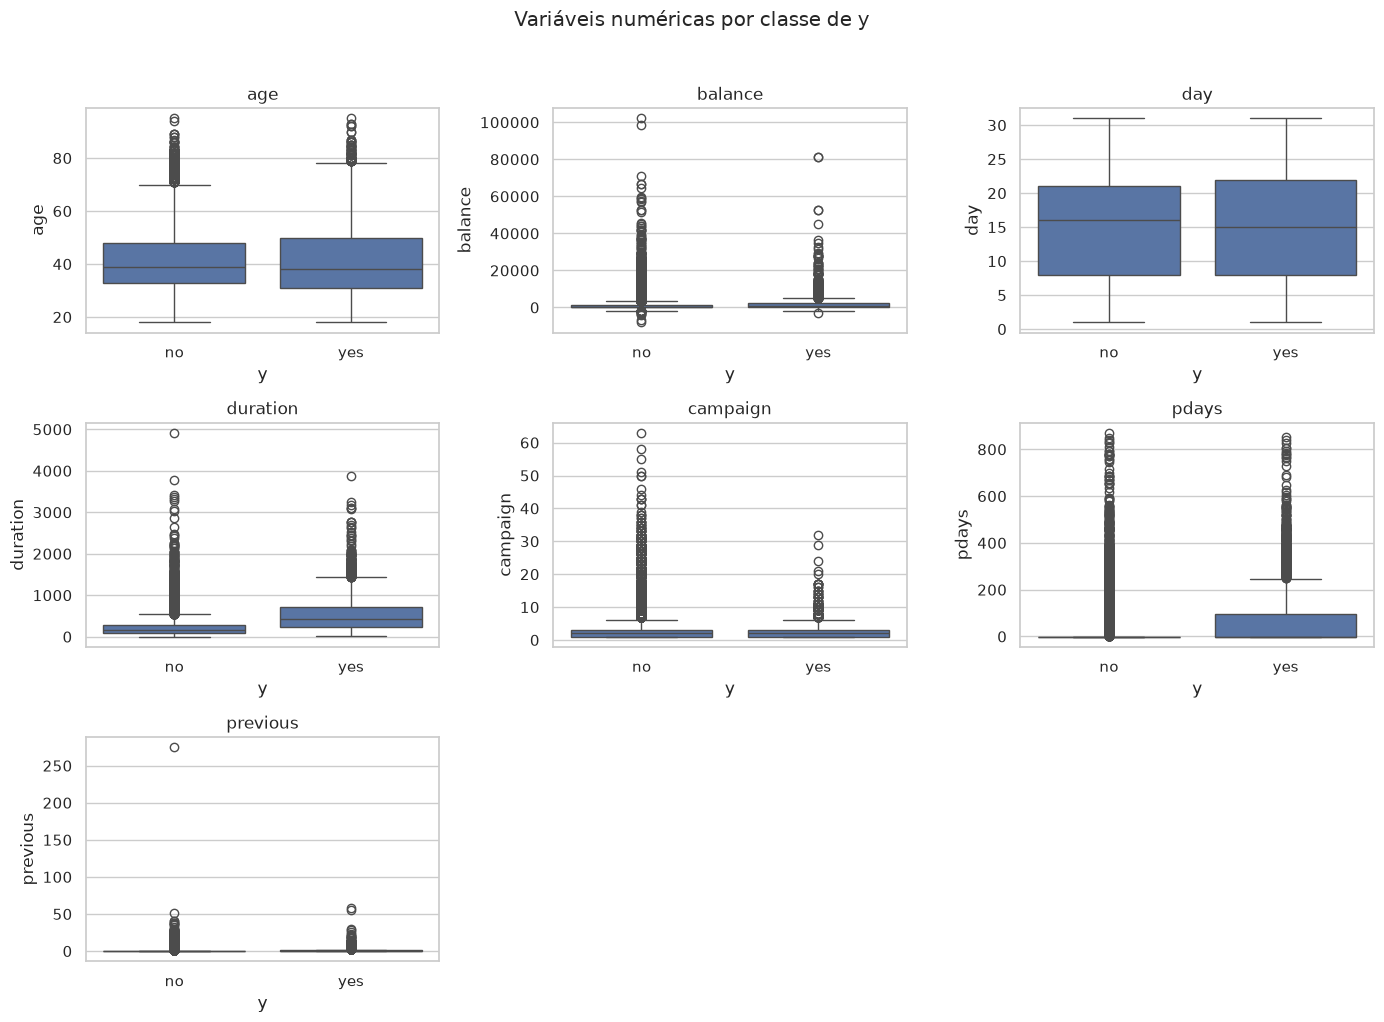

In [15]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()
for ax, col in zip(axes, NUM_COLS):
    sns.boxplot(data=bank_full_df, x="y", y=col, ax=ax)
    ax.set_title(col)
for ax in axes[len(NUM_COLS):]:
    ax.axis("off")
fig.suptitle("Variáveis numéricas por classe de y", y=1.02)
fig.tight_layout()
plt.show()

In [16]:
corr_with_y = (
    bank_full_df[NUM_COLS]
    .assign(y=y_binary)
    .corr()["y"]
    .drop("y")
    .sort_values(key=abs, ascending=False)
)
corr_with_y.to_frame("correlação com y")

,correlação com y
duration,0.394521
pdays,0.103621
previous,0.093236
campaign,-0.073172
balance,0.052838
day,-0.028348
age,0.025155


**Atenção — vazamento de dado (*data leakage*) em `duration`:** é a variável mais fortemente relacionada a `y`, tanto na correlação quanto nos boxplots acima. Mas `duration` só é conhecida *depois* que a ligação termina — no momento de decidir quem contatar, esse valor não existe. Usá-la como estava aqui deixaria o modelo com um desempenho artificialmente alto e inútil na prática. Vamos retomar esse ponto nas tarefas de Pré-processamento, Modelagem e Uso em produção (ex.: treinar/comparar um modelo sem `duration` para uso realista).

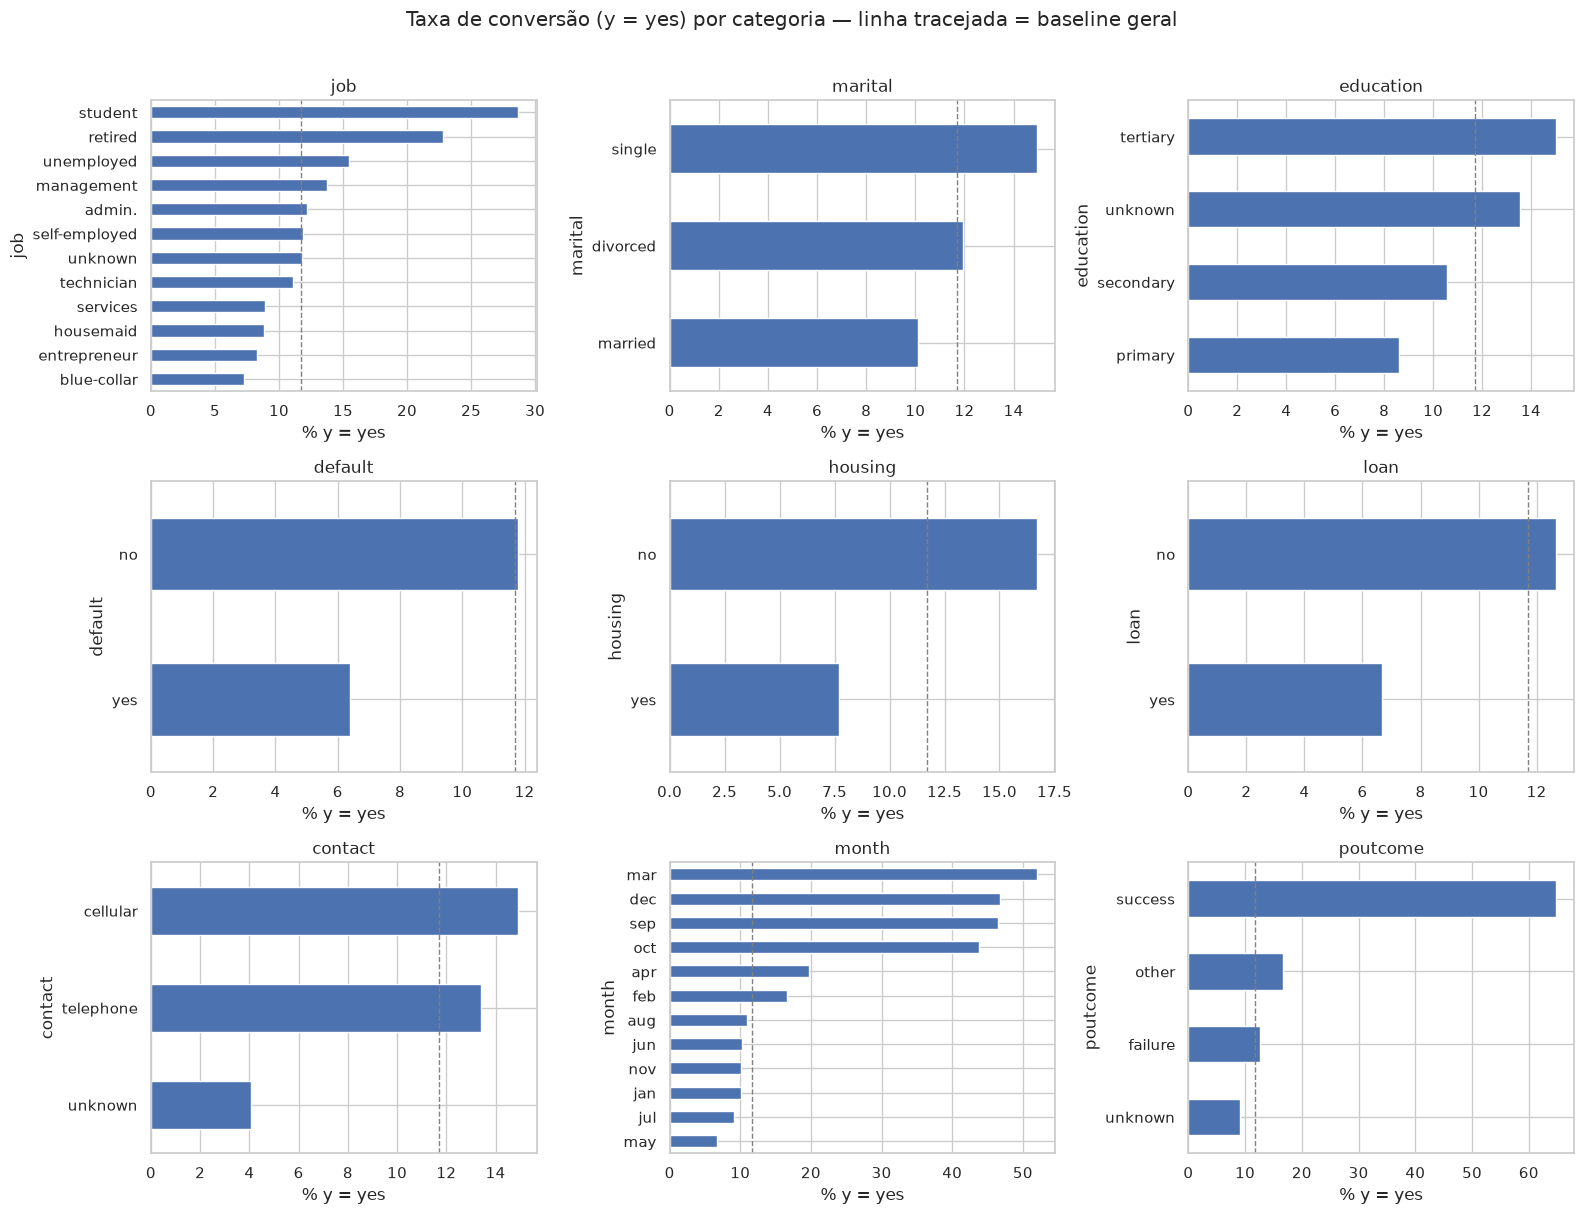

In [17]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for ax, col in zip(axes, CAT_COLS):
    rate = bank_full_df.groupby(col)["y"].apply(lambda s: (s == "yes").mean() * 100).sort_values()
    rate.plot(kind="barh", ax=ax)
    ax.axvline(baseline_rate, color="grey", linestyle="--", linewidth=1)
    ax.set_title(col)
    ax.set_xlabel("% y = yes")
for ax in axes[len(CAT_COLS):]:
    ax.axis("off")
fig.suptitle("Taxa de conversão (y = yes) por categoria — linha tracejada = baseline geral", y=1.01)
fig.tight_layout()
plt.show()

**Principais observações:** clientes com `poutcome == "success"` (campanha anterior bem-sucedida), `contact == "cellular"`, aposentados/estudantes (`job`), e contatados em meses como março/setembro/outubro/dezembro convertem bem acima do baseline geral. `pdays` e `previous` também se destacam entre as numéricas (ter sido contatado antes, e há pouco tempo, associa-se a maior conversão) — coerente com o padrão visto em `poutcome`.